# SNN Preprocessing + Hyperparameter Tuning

Tunes both preprocessing parameters (keypoint detection, grid binning, distance/aruco encoding)
and SNN hyperparameters jointly over raw training runs from the `Trening/` directory.

**Input structure per run:**
- `data.csv`: timestamp, image_filename, range_center_m, aruco_x_norm, cmd_linear_x, cmd_angular_z
- `images/`: grayscale PNG frames

**Strategy:** Keypoint detection is cached per (frame, FAST threshold) since it is the bottleneck.
All cheaper operations (binning, encoding, label mapping) run inside the tuning loop.

In [26]:
import cv2 as cv
import numpy as np
import pandas as pd
import itertools
import math
import sys
from pathlib import Path
from tqdm import tqdm

# Ensure the correct LIF_SNN_network is imported regardless of kernel working directory
_THIS_DIR = Path(__file__).parent if "__file__" in dir() else Path(r"C:\Users\eirik\Desktop\Bachelor\Python_Neural_Network\Python_implementation")
if str(_THIS_DIR) not in sys.path:
    sys.path.insert(0, str(_THIS_DIR))

from LIF_SNN_network import SNNLayer

np.random.seed(42)

## Paths & constants

In [27]:
TRENING_DIR = Path("../Trening")
RESULTS_DIR = Path("CSV_results")

FRAME_WIDTH  = 640
FRAME_HEIGHT = 480

# SNN output size (left / forward / right)
N_OUTPUTS = 3

## Preprocessing parameter ranges

| Parameter | Effect |
|---|---|
| `fast_threshold` | Detector sensitivity — higher = fewer, stronger corners |
| `response_cutoff` | Drop keypoints with FAST response below this value |
| `max_keypoints` | Cap on keypoints per frame (highest-response kept) |
| `n_bins_x / n_bins_y` | Grid resolution: columns × rows |
| `n_threshold_levels` | Number of count intervals for event-driven encoding |
| `threshold_max` | Upper bound of count range for interval edges |
| `n_dist_bits` | Thermometric distance bits — 1 = binary, >1 = closer → more spikes |
| `dist_max_m` | Max sensing range; thresholds spaced evenly from `dist_max_m` down to `dist_max_m / n_dist_bits` |
| `n_aruco_bins` | Lateral zones for aruco x-position encoding |
| `angular_dead_zone` | \|angular_z\| below this → classified as forward |

**Thermometric encoding example** with `n_dist_bits=4`, `dist_max_m=2.0`
(thresholds: 2.0 m, 1.5 m, 1.0 m, 0.5 m):

| Range | Spikes |
|---|---|
| > 2.0 m | `[0, 0, 0, 0]` |
| 1.5 – 2.0 m | `[1, 0, 0, 0]` |
| 1.0 – 1.5 m | `[1, 1, 0, 0]` |
| 0.5 – 1.0 m | `[1, 1, 1, 0]` |
| < 0.5 m | `[1, 1, 1, 1]` |

In [28]:
# --- Keypoint detection ---
fast_threshold_range    = [5, 10]       # FAST detector threshold
response_cutoff_range   = [0]    # min FAST response to keep
max_keypoints_range     = [500]    # max keypoints per frame

# --- Grid binning ---
n_bins_x_range          = [8]        # horizontal bins
n_bins_y_range          = [3]        # vertical bins

# --- Event encoding ---
n_threshold_levels_range = [10]     # number of count intervals
threshold_max_range      = [50]    # upper bound of per-bin count range
                                    # (max_keypoints / (n_bins_x * n_bins_y) ≈ 500/24 ≈ 20)

# --- Distance (thermometric) ---
# n_dist_bits=1 is equivalent to the original binary encoding.
# Thresholds are: dist_max_m, dist_max_m*(n-1)/n, ..., dist_max_m/n
n_dist_bits_range       = [3, 4, 5]    # number of thermometric bits
dist_max_m_range        = [1.5]   # max sensing range (metres)

# --- Aruco ---
n_aruco_bins_range      = [3, 5, 7]       # lateral position zones

# --- Label ---
angular_dead_zone_range = [0.15] # rad/s dead-zone for forward vs turn

## SNN hyperparameter ranges

In [ ]:
n_epochs = 25
n_runs   = 3

# Neuron
decay_range             = [64, 128, 256]   # membrane potential decay
threshold_range         = [512, 1024, 2048]  # firing threshold
reset_range             = [0]

# Synapse / learning
lr_shift_range          = [3, 4]   # learning rate shift (div by 2^shift)
initial_weight_range    = [None, 64]
t_pre_range             = [2, 3, 4]
t_post_range            = [2, 3, 4]
tau_e_shift_range       = [2, 3, 4]
dw_pos_range            = [32]
dw_neg_range            = [64]
min_weight_range        = [8]
max_weight_range        = [255]

# Reward shaping via dopamine_code (maps to dual-shift LUT in DOPAMINE_DECODE)
# Old mapping: shift=0 → code=1, shift=1 → code=2, shift=2 → code=4
reward_code_range = [4]   # code=4 → ×4 / 2^lr_shift (was reward_shift=2)
punish_code_range = [1]   # code=1 → ×1 / 2^lr_shift (was punish_shift=0)

mode_range = ['rstdp']

# Feedback neuron: fires when all outputs were zero last cycle
feedback_range = [False, True]

## Load run directories and split into train / test

In [30]:
run_dirs = sorted([d for d in TRENING_DIR.iterdir() if d.is_dir()])

split_idx  = int(len(run_dirs) * 0.8)
train_runs = run_dirs[:split_idx]
test_runs  = run_dirs[split_idx:]

print(f"Total runs : {len(run_dirs)}")
print(f"Train runs : {len(train_runs)}")
print(f"Test  runs : {len(test_runs)}")

# Pre-load all CSVs to avoid repeated disk reads inside the tuning loop
run_dfs = {}
for run_dir in run_dirs:
    run_dfs[run_dir] = pd.read_csv(run_dir / "data.csv")

total_train_frames = sum(len(run_dfs[d]) for d in train_runs)
total_test_frames  = sum(len(run_dfs[d]) for d in test_runs)
print(f"Train frames: {total_train_frames}  |  Test frames: {total_test_frames}")

Total runs : 21
Train runs : 16
Test  runs : 5
Train frames: 1359  |  Test frames: 364


## Pre-cache keypoints

FAST detection is the expensive step. Run it once per (frame, FAST threshold) and
store raw `(x, y, response)` tuples sorted by response descending.
All subsequent filtering and binning is cheap and can run inside the tuning loop.

In [ ]:
# keypoint_cache[(frame_path, fast_threshold)] = [(x, y, response), ...] sorted desc
keypoint_cache = {}

unique_fast_thresholds = sorted(set(fast_threshold_range))

for fast_thr in unique_fast_thresholds:
    detector = cv.FastFeatureDetector_create(threshold=int(fast_thr))
    detector.setNonmaxSuppression(True)

    for run_dir in tqdm(run_dirs, desc=f"Caching keypoints  FAST thr={fast_thr}"):
        df         = run_dfs[run_dir]
        images_dir = run_dir / "images"

        for _, row in df.iterrows():
            frame_path = str(images_dir / row["image_filename"])
            key        = (frame_path, fast_thr)

            if key in keypoint_cache:
                continue

            img = cv.imread(frame_path, cv.IMREAD_GRAYSCALE)
            if img is None:
                keypoint_cache[key] = []
                continue

            kps = detector.detect(img, None)
            # Sort by response descending so slicing gives top-N cheaply
            keypoint_cache[key] = sorted(
                [(kp.pt[0], kp.pt[1], kp.response) for kp in kps],
                key=lambda t: t[2],
                reverse=True,
            )

print(f"\nCached {len(keypoint_cache)} (frame, detector) combinations.")

Caching keypoints  FAST thr=5:   5%|▍         | 1/21 [00:00<00:09,  2.20it/s]

## Preprocessing helper functions

In [ ]:
def get_bin_counts(frame_path, fast_threshold, response_cutoff, max_keypoints,
                   n_bins_x, n_bins_y):
    """Return flattened keypoint histogram for a single frame."""
    raw = keypoint_cache.get((frame_path, fast_threshold), [])

    # Cache is sorted by response descending; apply cutoff then cap
    filtered = [(x, y) for x, y, r in raw if r >= response_cutoff]
    filtered = filtered[:max_keypoints]

    if not filtered:
        return [0.0] * (n_bins_x * n_bins_y)

    x_coords, y_coords = zip(*filtered)
    hist, _, _ = np.histogram2d(
        x=x_coords, y=y_coords,
        bins=[n_bins_x, n_bins_y],
        range=[[0, FRAME_WIDTH], [0, FRAME_HEIGHT]],
    )
    return hist.flatten().tolist()


def encode_events(kp_counts, kp_counts_prev, threshold_edges):
    """Event-driven spike: fires when keypoint count crosses a threshold interval.

    threshold_edges must start at 1 (not 0) so that empty bins (count=0) fall
    into digitize index 0, making 0↔nonzero transitions detectable.

    Vectorised: replaces per-element np.digitize scalar calls with two
    array-wise digitize operations, then a single inequality comparison.
    """
    if kp_counts_prev is None:
        return [0] * len(kp_counts)
    new_idx  = np.digitize(kp_counts,      threshold_edges)
    prev_idx = np.digitize(kp_counts_prev, threshold_edges)
    return (new_idx != prev_idx).astype(np.int8).tolist()


def encode_distance(range_m, n_dist_bits, dist_max_m):
    """
    Thermometric distance encoding.

    Produces n_dist_bits spikes with evenly-spaced thresholds from
    dist_max_m down to dist_max_m / n_dist_bits.  Each bit is 1 when
    range_m is closer than its threshold, so a near object saturates
    all bits and a far object fires none.

    n_dist_bits=1 is identical to the old binary encoding with
    threshold = dist_max_m.

    Returns all-zero on NaN (sensor not available).
    """
    if pd.isna(range_m):
        return [0] * n_dist_bits

    # Thresholds evenly spaced: [dist_max_m, ..., dist_max_m/n_dist_bits]
    thresholds = np.linspace(dist_max_m, dist_max_m / n_dist_bits, n_dist_bits)
    return [1 if range_m < thr else 0 for thr in thresholds]


def encode_aruco(aruco_x_norm, n_aruco_bins):
    """
    One-hot encode normalised aruco x-position into n_aruco_bins lateral zones.
    Returns all-zero when tag not visible (aruco_x_norm is NaN).
    """
    if pd.isna(aruco_x_norm):
        return [0] * n_aruco_bins

    bin_edges = np.linspace(0, 1, n_aruco_bins + 1)
    spikes    = [0] * n_aruco_bins

    # Clamp to last bin for x == 1.0
    idx = min(int(np.digitize(aruco_x_norm, bin_edges)) - 1, n_aruco_bins - 1)
    idx = max(idx, 0)
    spikes[idx] = 1
    return spikes


def derive_label(cmd_angular_z, angular_dead_zone):
    """Map angular velocity command to output neuron index (0=left, 1=fwd, 2=right)."""
    if cmd_angular_z > angular_dead_zone:
        return 0   # turn left
    elif cmd_angular_z < -angular_dead_zone:
        return 2   # turn right
    else:
        return 1   # forward / stop


def preprocess_dataset(run_list, fast_threshold, response_cutoff, max_keypoints,
                        n_bins_x, n_bins_y, n_threshold_levels, threshold_max,
                        n_dist_bits, dist_max_m, n_aruco_bins, angular_dead_zone):
    """
    Convert a list of run directories into aligned (spikes, labels) lists.

    Returns
    -------
    all_spikes : list[list[int]]
    all_labels : list[int]
    n_inputs   : int   — derived from grid + dist bits + aruco dims
    """
    # Edges start at 1 so empty bins (count=0) land in digitize index 0,
    # making the 0 ↔ nonzero transition detectable as a spike.
    threshold_edges = np.linspace(1, threshold_max, n_threshold_levels)
    n_inputs        = n_bins_x * n_bins_y + n_dist_bits + n_aruco_bins

    all_spikes, all_labels = [], []

    for run_dir in run_list:
        df         = run_dfs[run_dir]
        images_dir = run_dir / "images"
        kp_counts_prev = None

        for _, row in df.iterrows():
            frame_path = str(images_dir / row["image_filename"])

            # Keypoint grid → event spikes
            kp_counts  = get_bin_counts(frame_path, fast_threshold, response_cutoff,
                                        max_keypoints, n_bins_x, n_bins_y)
            kp_spikes  = encode_events(kp_counts, kp_counts_prev, threshold_edges)
            kp_counts_prev = kp_counts

            dist_spikes  = encode_distance(row["range_center_m"], n_dist_bits, dist_max_m)
            aruco_spikes = encode_aruco(row["aruco_x_norm"], n_aruco_bins)
            label        = derive_label(row["cmd_angular_z"], angular_dead_zone)

            all_spikes.append(kp_spikes + dist_spikes + aruco_spikes)
            all_labels.append(label)

    return all_spikes, all_labels, n_inputs

In [ ]:
def parse_aruco_state(spike_row, aruco_start, n_aruco):
    aruco = spike_row[aruco_start : aruco_start + n_aruco]
    seen  = bool(aruco.any())
    if not seen:
        return False, 0
    b = int(np.argmax(aruco))
    c = n_aruco // 2
    return True, (0 if b == c else (-1 if b < c else +1))


def reward_signal(seen, pos, action_idx, reward_code, punish_code):
    """Returns (dopamine_code, dopamine_sign, dopamine_enable)."""
    if seen and (
        (pos == 0  and action_idx == 1) or
        (pos == -1 and action_idx == 0) or
        (pos == +1 and action_idx == 2)
    ):
        return reward_code, 1, 1   # correct alignment action: reward

    if not seen and action_idx in (0, 2):
        return 1, 1, 1             # searching: weak reward (code=1 → ×1)

    return punish_code, 0, 1      # everything else: punish

## Compute total configurations

In [ ]:
preproc_ranges = [
    fast_threshold_range, response_cutoff_range, max_keypoints_range,
    n_bins_x_range, n_bins_y_range,
    n_threshold_levels_range, threshold_max_range,
    n_dist_bits_range, dist_max_m_range,
    n_aruco_bins_range,
    angular_dead_zone_range,
]

snn_ranges = [
    decay_range, threshold_range, reset_range,
    lr_shift_range, initial_weight_range,
    t_pre_range, t_post_range, tau_e_shift_range,
    dw_pos_range, dw_neg_range,
    min_weight_range, max_weight_range,
    reward_code_range, punish_code_range,
    mode_range,
    feedback_range,
]

n_preproc_configs = math.prod(map(len, preproc_ranges))
n_snn_configs     = math.prod(map(len, snn_ranges))
total_configs     = n_preproc_configs * n_snn_configs

print(f"Preprocessing configs : {n_preproc_configs}")
print(f"SNN configs           : {n_snn_configs}")
print(f"Total configurations  : {total_configs}")

## Precompute spike components

Each preprocessing parameter only affects a subset of the spike encoding.
By computing each component once per unique parameter combination — rather than
once per full config — we reduce `get_bin_counts` calls from
**3072 × 1723 = 5.3 M** down to **72 × 1723 = 124 k** (43×), eliminate
`df.iterrows()` overhead, and allow the tuning loop to work directly with
pre-built numpy arrays instead of Python lists.

In [ ]:
# ── 1. Extract per-run sensor columns as numpy arrays (avoids df.iterrows overhead) ──
run_frame_data = {}
for run_dir in run_dirs:
    df         = run_dfs[run_dir]
    images_dir = run_dir / "images"
    run_frame_data[run_dir] = {
        "frame_paths": [str(images_dir / fn) for fn in df["image_filename"]],
        "range_m":     df["range_center_m"].to_numpy(dtype=np.float64),
        "aruco_x":     df["aruco_x_norm"].to_numpy(dtype=np.float64),
        "angular_z":   df["cmd_angular_z"].to_numpy(dtype=np.float64),
    }

# ── 2. Keypoint-count arrays ─ unique (fast_thr, resp_cutoff, max_kp, n_bins_x, n_bins_y) ──
unique_kp_cfgs = list(itertools.product(
    fast_threshold_range, response_cutoff_range, max_keypoints_range,
    n_bins_x_range, n_bins_y_range,
))
kp_counts_store = {}
for cfg in tqdm(unique_kp_cfgs, desc="kp_counts"):
    fast_thr, resp_cutoff, max_kp, nbx, nby = cfg
    n_bins = nbx * nby
    kp_counts_store[cfg] = {}
    for run_dir in run_dirs:
        fps      = run_frame_data[run_dir]["frame_paths"]
        arr      = np.zeros((len(fps), n_bins), dtype=np.float32)
        for i, fp in enumerate(fps):
            arr[i] = get_bin_counts(fp, fast_thr, resp_cutoff, max_kp, nbx, nby)
        kp_counts_store[cfg][run_dir] = arr

# ── 3. Event-spike arrays ─ unique (...kp params..., n_threshold_levels, threshold_max) ──
unique_event_cfgs = list(itertools.product(
    fast_threshold_range, response_cutoff_range, max_keypoints_range,
    n_bins_x_range, n_bins_y_range,
    n_threshold_levels_range, threshold_max_range,
))
event_spike_store = {}
for cfg in tqdm(unique_event_cfgs, desc="event spikes"):
    fast_thr, resp_cutoff, max_kp, nbx, nby, n_thresh, thresh_max = cfg
    kp_key = (fast_thr, resp_cutoff, max_kp, nbx, nby)
    # Edges start at 1 so empty bins (count=0) land in digitize index 0,
    # making the 0 ↔ nonzero transition detectable as a spike.
    edges  = np.linspace(1, thresh_max, n_thresh)
    n_bins = nbx * nby
    event_spike_store[cfg] = {}
    for run_dir in run_dirs:
        counts   = kp_counts_store[kp_key][run_dir]   # (n_frames, n_bins)
        n_frames = len(counts)
        spikes   = np.zeros((n_frames, n_bins), dtype=np.int32)
        if n_frames > 1:
            # Vectorise encode_events across the entire run at once
            new_idx  = np.digitize(counts[1:], edges)   # (n_frames-1, n_bins)
            prev_idx = np.digitize(counts[:-1], edges)
            spikes[1:] = (new_idx != prev_idx).astype(np.int32)
        event_spike_store[cfg][run_dir] = spikes

# ── 4. Distance-spike arrays ─ unique (n_dist_bits, dist_max_m) ──
dist_spike_store = {}
for cfg in itertools.product(n_dist_bits_range, dist_max_m_range):
    n_dist_bits_v, dist_max_m_v = cfg
    thresholds = np.linspace(dist_max_m_v, dist_max_m_v / n_dist_bits_v, n_dist_bits_v)
    dist_spike_store[cfg] = {}
    for run_dir in run_dirs:
        rng    = run_frame_data[run_dir]["range_m"]
        spikes = np.zeros((len(rng), n_dist_bits_v), dtype=np.int32)
        valid  = ~np.isnan(rng)
        if valid.any():
            spikes[valid] = (rng[valid, np.newaxis] < thresholds).astype(np.int32)
        dist_spike_store[cfg][run_dir] = spikes

# ── 5. Aruco-spike arrays ─ unique n_aruco_bins ──
aruco_spike_store = {}
for n_aruco in n_aruco_bins_range:
    bin_edges = np.linspace(0, 1, n_aruco + 1)
    aruco_spike_store[n_aruco] = {}
    for run_dir in run_dirs:
        aruco_x = run_frame_data[run_dir]["aruco_x"]
        spikes  = np.zeros((len(aruco_x), n_aruco), dtype=np.int32)
        valid   = ~np.isnan(aruco_x)
        if valid.any():
            idxs = np.clip(np.digitize(aruco_x[valid], bin_edges) - 1, 0, n_aruco - 1)
            spikes[np.where(valid)[0], idxs] = 1
        aruco_spike_store[n_aruco][run_dir] = spikes

# ── 6. Label arrays ─ unique angular_dead_zone ──
label_store = {}
for ang_dead in angular_dead_zone_range:
    label_store[ang_dead] = {}
    for run_dir in run_dirs:
        az = run_frame_data[run_dir]["angular_z"]
        label_store[ang_dead][run_dir] = np.where(az > ang_dead, 0,
                                         np.where(az < -ang_dead, 2, 1)).astype(np.int8)

print("All spike components precomputed.")

event spikes: 100%|██████████| 4/4 [00:00<00:00, 1310.21it/s]

All spike components precomputed.


## Save spike train datasets to CSV

Saves the train and test spike train datasets (assembled from precomputed stores) to CSV files
using the first configuration from each parameter range. Each row is one frame; columns are
the spike values for each input neuron followed by the class label.

In [ ]:
def build_dataset(run_list, event_key, dist_key, n_aruco, ang_dead):
    """Assemble (n_frames, n_inputs) spike matrix and label vector from precomputed stores."""
    spike_parts = [np.concatenate([event_spike_store[event_key][r],
                                   dist_spike_store[dist_key][r],
                                   aruco_spike_store[n_aruco][r]], axis=1)
                   for r in run_list]
    label_parts = [label_store[ang_dead][r] for r in run_list]
    return np.vstack(spike_parts), np.concatenate(label_parts)

In [ ]:
# Use the first value from each parameter range to build the spike datasets
_fast_thr      = fast_threshold_range[0]
_resp_cutoff   = response_cutoff_range[0]
_max_kp        = max_keypoints_range[0]
_n_bins_x      = n_bins_x_range[0]
_n_bins_y      = n_bins_y_range[0]
_n_thresh_lvls = n_threshold_levels_range[0]
_thresh_max    = threshold_max_range[0]
_n_dist_bits   = n_dist_bits_range[0]
_dist_max_m    = dist_max_m_range[0]
_n_aruco       = n_aruco_bins_range[0]
_ang_dead      = angular_dead_zone_range[0]

_event_key = (_fast_thr, _resp_cutoff, _max_kp, _n_bins_x, _n_bins_y, _n_thresh_lvls, _thresh_max)
_dist_key  = (_n_dist_bits, _dist_max_m)
_n_inputs  = _n_bins_x * _n_bins_y + _n_dist_bits + _n_aruco

train_spikes_save, train_labels_save = build_dataset(train_runs, _event_key, _dist_key, _n_aruco, _ang_dead)
test_spikes_save,  test_labels_save  = build_dataset(test_runs,  _event_key, _dist_key, _n_aruco, _ang_dead)

# Column names: spike_0 .. spike_N, label
spike_cols = [f"spike_{i}" for i in range(_n_inputs)]

train_df = pd.DataFrame(train_spikes_save, columns=spike_cols)
train_df["label"] = train_labels_save

test_df = pd.DataFrame(test_spikes_save, columns=spike_cols)
test_df["label"] = test_labels_save

train_out = RESULTS_DIR / "train_spike_trains.csv"
test_out  = RESULTS_DIR / "test_spike_trains.csv"

train_df.to_csv(train_out, index=False)
test_df.to_csv(test_out,  index=False)

print(f"Saved train spike trains : {train_df.shape}  →  {train_out}")
print(f"Saved test  spike trains : {test_df.shape}   →  {test_out}")

Saved train spike trains : (1359, 24)  →  CSV_results\train_spike_trains.csv
Saved test  spike trains : (364, 24)   →  CSV_results\test_spike_trains.csv


In [ ]:
tuning_results = []

preproc_product = list(itertools.product(*preproc_ranges))
snn_product     = list(itertools.product(*snn_ranges))

for preproc_config in tqdm(preproc_product, desc="Preprocessing configs"):
    (
        fast_thr, resp_cutoff, max_kp,
        n_bins_x, n_bins_y,
        n_thresh_lvls, thresh_max,
        n_dist_bits, dist_max_m,
        n_aruco, ang_dead,
    ) = preproc_config

    event_key   = (fast_thr, resp_cutoff, max_kp, n_bins_x, n_bins_y, n_thresh_lvls, thresh_max)
    dist_key    = (n_dist_bits, dist_max_m)
    n_inputs    = n_bins_x * n_bins_y + n_dist_bits + n_aruco
    aruco_start = n_bins_x * n_bins_y + n_dist_bits

    train_spikes, train_labels = build_dataset(train_runs, event_key, dist_key, n_aruco, ang_dead)
    test_spikes,  test_labels  = build_dataset(test_runs,  event_key, dist_key, n_aruco, ang_dead)

    n_train = len(train_labels)
    n_test  = len(test_labels)

    for snn_config in snn_product:
        (
            decay, threshold, reset,
            lr_shift, initial_weight,
            t_pre, t_post, tau_e_shift,
            dw_pos, dw_neg,
            min_weight, max_weight,
            rew_code, pun_code,
            mode,
            feedback,
        ) = snn_config

        neuron_params  = {"decay": decay, "threshold": threshold, "reset": reset}
        synapse_params = {
            "lr_shift": lr_shift, "w_init": initial_weight,
            "t_pre": t_pre, "t_post": t_post, "tau_e_shift": tau_e_shift,
            "dw_pos": dw_pos, "dw_neg": dw_neg,
            "w_min": min_weight, "w_max": max_weight,
            "mode": mode,
        }

        all_run_train_accs = []
        all_run_test_accs  = []

        for _ in range(n_runs):
            SNN = SNNLayer(
                n_inputs=n_inputs, n_outputs=N_OUTPUTS,
                neuron_params=neuron_params, synapse_params=synapse_params,
                feedback=feedback,
            )

            epoch_train_accs = []
            epoch_test_accs  = []

            for _ in range(n_epochs):
                # --- Training ---
                SNN.reset_state()
                n_correct = 0
                for i in range(n_train):
                    output_spikes = SNN.forward(train_spikes[i])
                    winner        = SNN.winner_takes_all(output_spikes)

                    seen, pos           = parse_aruco_state(train_spikes[i], aruco_start, n_aruco)
                    code, sign, enable  = reward_signal(seen, pos, winner, rew_code, pun_code)
                    if enable:
                        SNN.apply_reward(dopamine_code=code, dopamine_sign=sign, winner_idx=winner)

                    if winner == int(train_labels[i]):
                        n_correct += 1
                epoch_train_accs.append(n_correct / n_train)

                # --- Testing (no weight updates) ---
                SNN.reset_state()
                n_test_correct = sum(
                    1 for i in range(n_test)
                    if SNN.winner_takes_all(SNN.forward(test_spikes[i])) == int(test_labels[i])
                )
                epoch_test_accs.append(n_test_correct / n_test)

            all_run_train_accs.append(np.mean(epoch_train_accs))
            all_run_test_accs.append(np.mean(epoch_test_accs))

        tuning_results.append({
            # Preprocessing
            "fast_threshold":      fast_thr,
            "response_cutoff":     resp_cutoff,
            "max_keypoints":       max_kp,
            "n_bins_x":            n_bins_x,
            "n_bins_y":            n_bins_y,
            "n_threshold_levels":  n_thresh_lvls,
            "threshold_max":       thresh_max,
            "n_dist_bits":         n_dist_bits,
            "dist_max_m":          dist_max_m,
            "n_aruco_bins":        n_aruco,
            "angular_dead_zone":   ang_dead,
            "n_inputs":            n_inputs,
            # SNN
            "decay":               decay,
            "threshold":           threshold,
            "reset":               reset,
            "lr_shift":            lr_shift,
            "w_init":              initial_weight,
            "t_pre":               t_pre,
            "t_post":              t_post,
            "tau_e_shift":         tau_e_shift,
            "dw_pos":              dw_pos,
            "dw_neg":              dw_neg,
            "w_min":               min_weight,
            "w_max":               max_weight,
            "mode":                mode,
            "reward_code":         rew_code,
            "punish_code":         pun_code,
            "feedback":            feedback,
            # Results
            "mean_train_acc":  np.mean(all_run_train_accs),
            "std_train_acc":   np.std(all_run_train_accs),
            "mean_test_acc":   np.mean(all_run_test_accs),
            "std_test_acc":    np.std(all_run_test_accs),
        })

print(f"\nFinished. {len(tuning_results)} configurations evaluated.")

## Save results

In [ ]:
df_results = pd.DataFrame(tuning_results)
out_path   = RESULTS_DIR / "preprocessing_tuning_results.csv"
df_results.to_csv(out_path, index=False)
print(f"Saved {len(df_results)} rows → {out_path}")

Saved 1296 rows → CSV_results\preprocessing_tuning_results.csv


## Analysis

In [ ]:
df = pd.read_csv(RESULTS_DIR / "preprocessing_tuning_results.csv")

top_10 = df.sort_values("mean_test_acc", ascending=False).head(10)

preproc_cols = [
    "fast_threshold", "response_cutoff", "max_keypoints",
    "n_bins_x", "n_bins_y", "n_threshold_levels", "threshold_max",
    "n_dist_bits", "dist_max_m",
    "n_aruco_bins", "angular_dead_zone", "n_inputs",
]
metric_cols = ["mean_test_acc", "std_test_acc", "mean_train_acc"]

print("=== Top 10 configurations ===")
print(top_10[metric_cols + preproc_cols].to_string(index=False))

=== Top 10 configurations ===
 mean_test_acc  std_test_acc  mean_train_acc  fast_threshold  response_cutoff  max_keypoints  n_bins_x  n_bins_y  n_threshold_levels  threshold_max  n_dist_bits  dist_max_m  n_aruco_bins  angular_dead_zone  n_inputs
      0.610165      0.001264        0.202384              10                0            500         8         3                  10             50            4         1.5             7               0.15        35
      0.608736      0.000604        0.204533              10                0            500         8         3                  10             50            4         1.5             7               0.15        35
      0.607582      0.000000        0.200383              10                0            500         8         3                  10             50            4         1.5             7               0.15        35
      0.606593      0.000000        0.204739              10                0            500         8    

In [ ]:
print("=== Mean test accuracy by preprocessing parameter ===\n")

for col in preproc_cols[:-1]:   # skip n_inputs (derived)
    print(f"  {col}:")
    print(df.groupby(col)["mean_test_acc"].mean().round(4).to_string())
    print()

=== Mean test accuracy by preprocessing parameter ===

  fast_threshold:
fast_threshold
10    0.5965

  response_cutoff:
response_cutoff
0    0.5965

  max_keypoints:
max_keypoints
500    0.5965

  n_bins_x:
n_bins_x
4    0.5972
8    0.5958

  n_bins_y:
n_bins_y
3    0.5979
6    0.5951

  n_threshold_levels:
n_threshold_levels
10    0.5965

  threshold_max:
threshold_max
50    0.5965

  n_dist_bits:
n_dist_bits
4    0.5965

  dist_max_m:
dist_max_m
1.5    0.5965

  n_aruco_bins:
n_aruco_bins
7    0.5965

  angular_dead_zone:
angular_dead_zone
0.15    0.5965



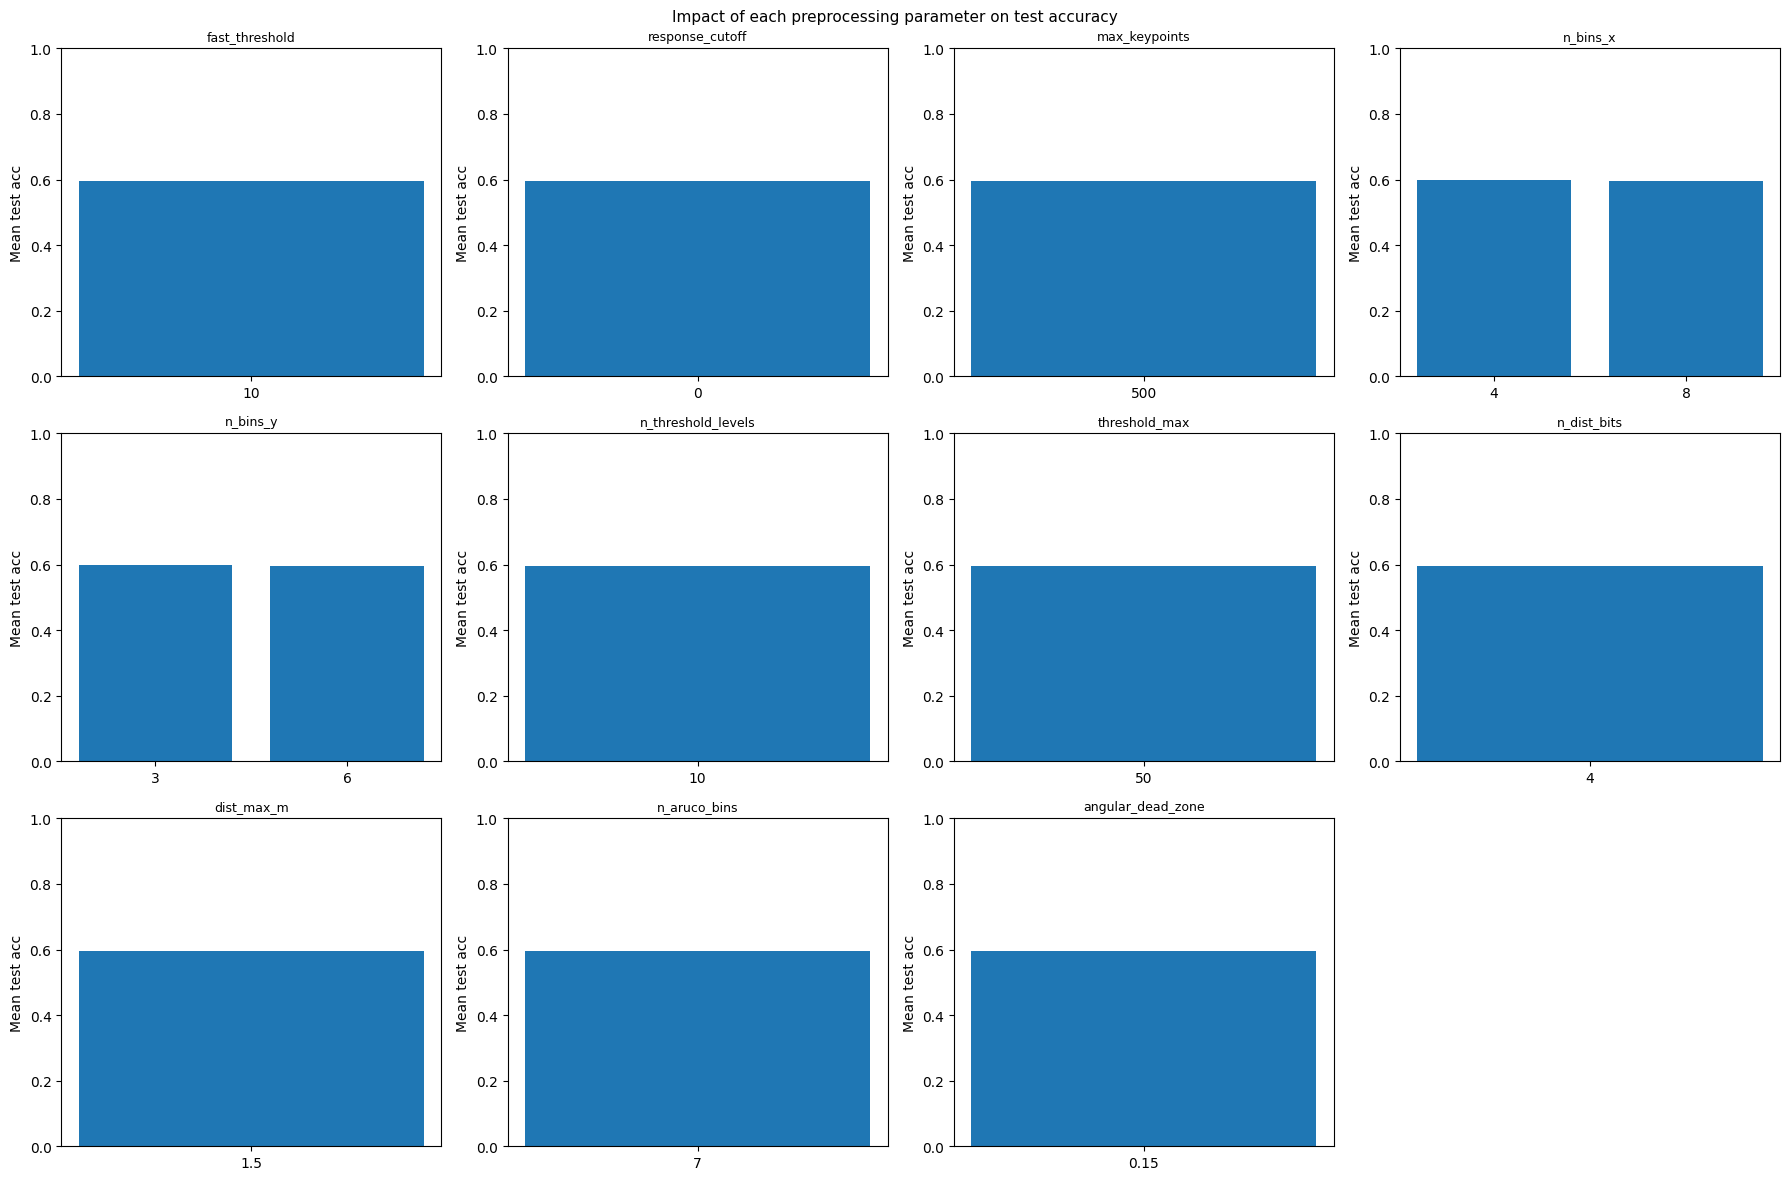

In [ ]:
import matplotlib.pyplot as plt

tune_cols = preproc_cols[:-1]   # exclude n_inputs (derived)
n_cols    = 4
n_rows    = math.ceil(len(tune_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for ax, col in zip(axes, tune_cols):
    grouped = df.groupby(col)["mean_test_acc"].mean()
    ax.bar([str(v) for v in grouped.index], grouped.values)
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("Mean test acc")
    ax.set_ylim(0, 1)

# Hide any unused subplots
for ax in axes[len(tune_cols):]:
    ax.set_visible(False)

plt.suptitle("Impact of each preprocessing parameter on test accuracy", fontsize=11)
plt.tight_layout()
plt.show()

## SNN Hyperparameter Statistics

In [ ]:
snn_cols = [
    "decay", "threshold", "reset",
    "lr_shift", "w_init", "t_pre", "t_post", "tau_e_shift",
    "dw_pos", "dw_neg", "w_min", "w_max",
    "reward_code", "punish_code",
    "mode", "feedback",
]

print("=== Mean test accuracy by SNN hyperparameter ===\n")
for col in snn_cols:
    print(f"  {col}:")
    print(df.groupby(col)["mean_test_acc"].mean().round(4).to_string())
    print()

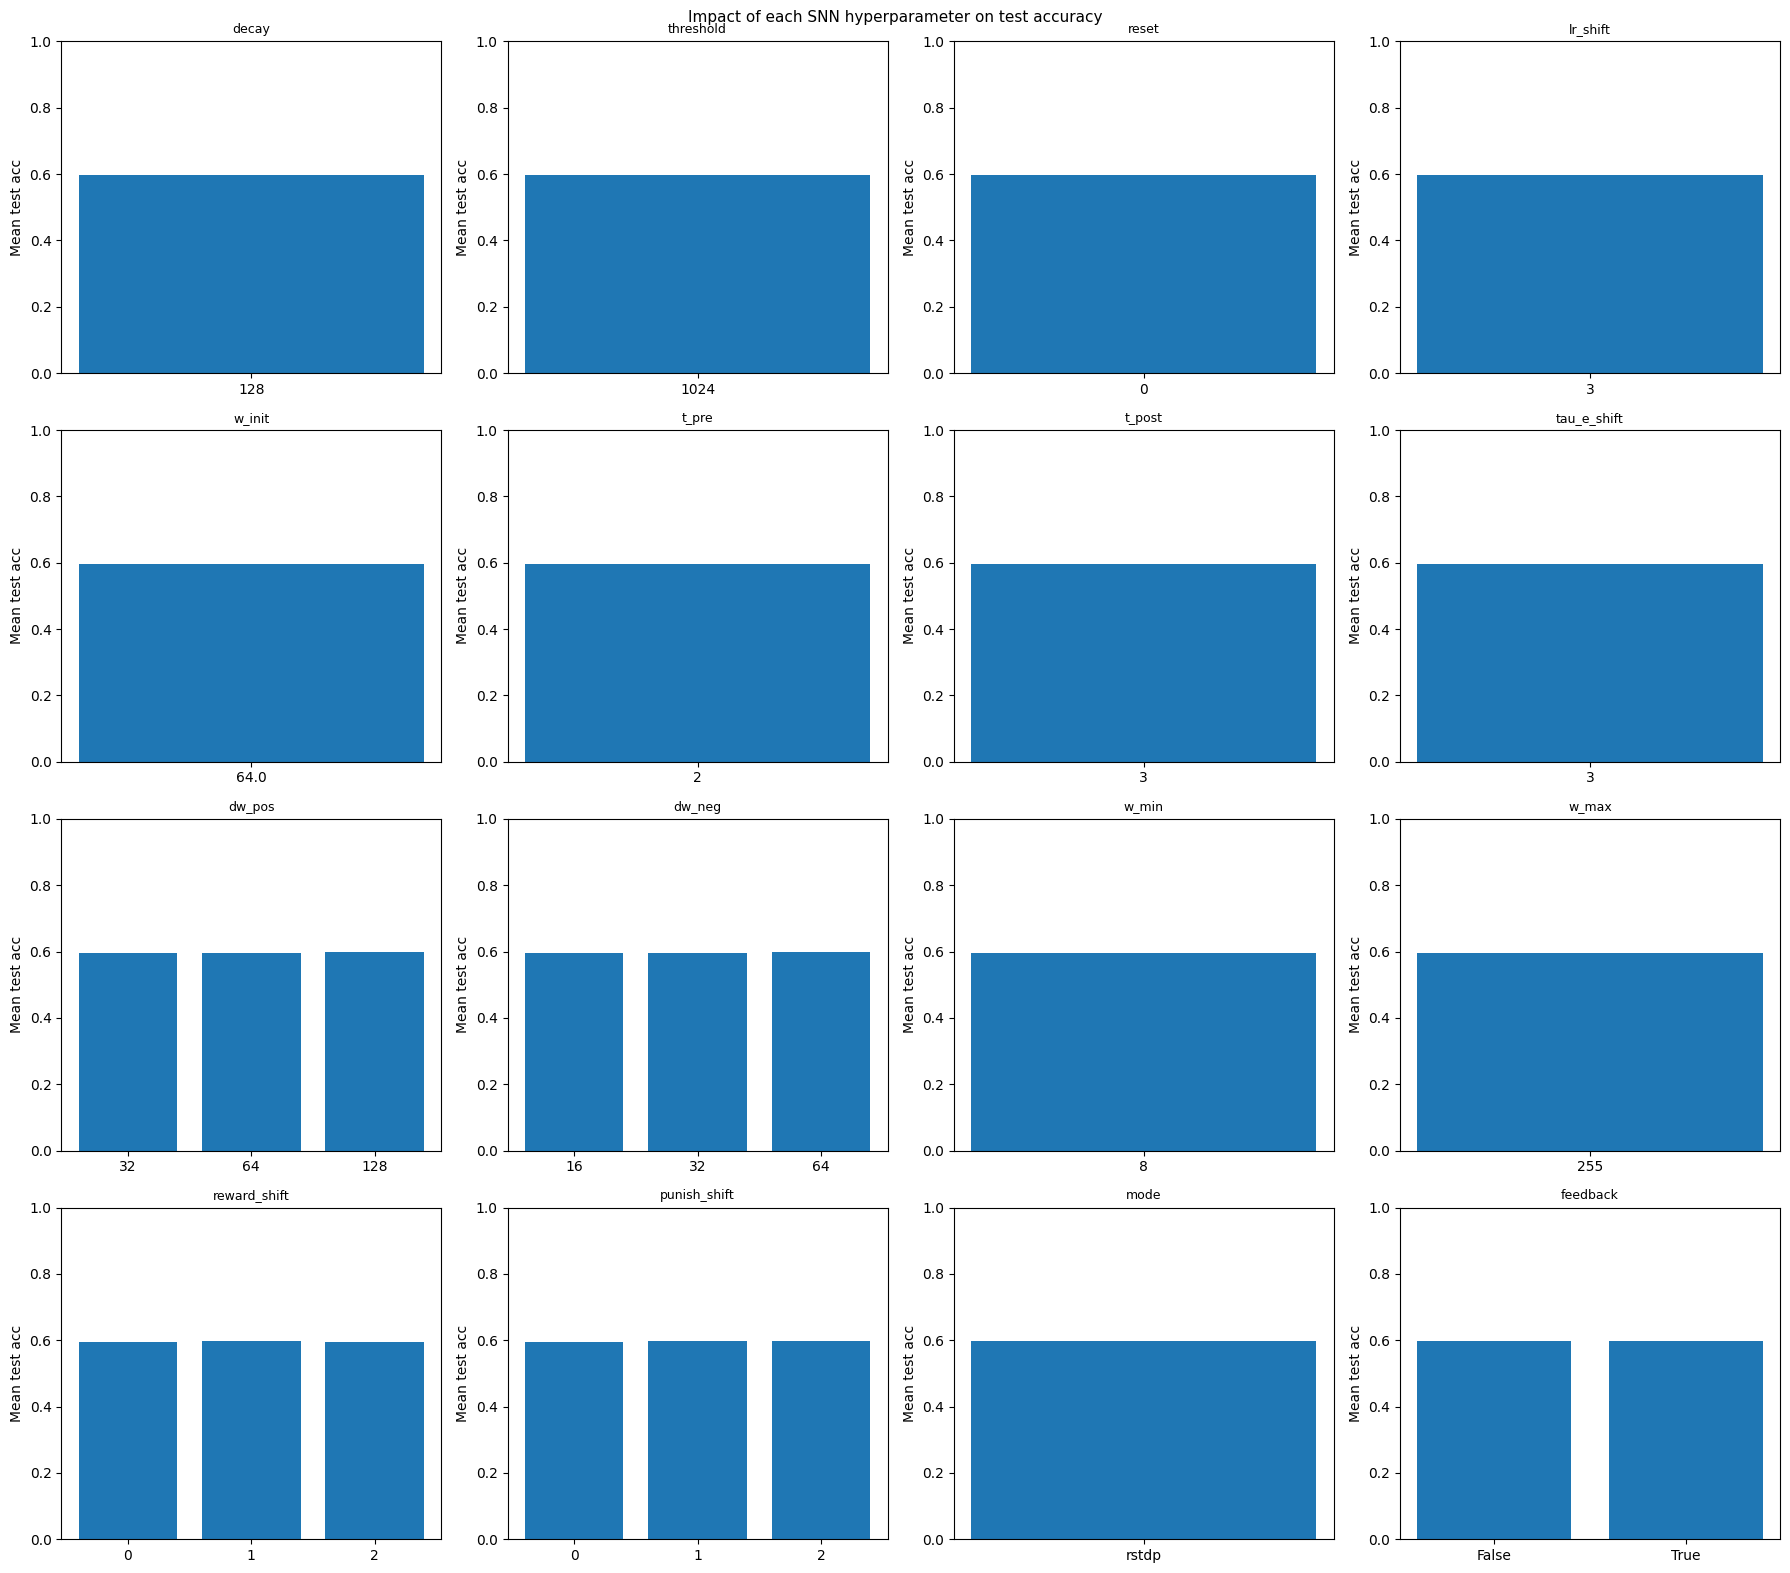

In [ ]:
n_cols = 4
n_rows = math.ceil(len(snn_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for ax, col in zip(axes, snn_cols):
    grouped = df.groupby(col)["mean_test_acc"].mean()
    ax.bar([str(v) for v in grouped.index], grouped.values)
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("Mean test acc")
    ax.set_ylim(0, 1)

for ax in axes[len(snn_cols):]:
    ax.set_visible(False)

plt.suptitle("Impact of each SNN hyperparameter on test accuracy", fontsize=11)
plt.tight_layout()
plt.show()